# Practical example

## Importing the relevant libraries

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
sns.set()

## Loading the raw data

In [2]:
raw_data = pd.read_csv('1.04. Real-life example.csv')
raw_data

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4
...,...,...,...,...,...,...,...,...,...
4340,Mercedes-Benz,125000.0,sedan,9,3.0,Diesel,yes,2014,S 350
4341,BMW,6500.0,sedan,1,3.5,Petrol,yes,1999,535
4342,BMW,8000.0,sedan,194,2.0,Petrol,yes,1985,520
4343,Toyota,14200.0,sedan,31,NaN,Petrol,yes,2014,Corolla


## Preprocessing

### Exploring the descriptive statistics of the variables

In [3]:
raw_data.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
count,4345,4173.000000,4345,4345.000000,4195.000000,4345,4345,4345.000000,4345
unique,7,NaN,6,NaN,NaN,4,2,NaN,312
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN,E-Class
freq,936,NaN,1649,NaN,NaN,2019,3947,NaN,199
mean,NaN,19418.746935,NaN,161.237284,2.790734,NaN,NaN,2006.550058,NaN
std,NaN,25584.242620,NaN,105.705797,5.066437,NaN,NaN,6.719097,NaN
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000,NaN
25%,NaN,6999.000000,NaN,86.000000,1.800000,NaN,NaN,2003.000000,NaN
50%,NaN,11500.000000,NaN,155.000000,2.200000,NaN,NaN,2008.000000,NaN
75%,NaN,21700.000000,NaN,230.000000,3.000000,NaN,NaN,2012.000000,NaN


### Determining the variables of interest

In [4]:
data = raw_data.drop(['Model'],axis=1)
data.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
count,4345,4173.000000,4345,4345.000000,4195.000000,4345,4345,4345.000000
unique,7,NaN,6,NaN,NaN,4,2,NaN
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN
freq,936,NaN,1649,NaN,NaN,2019,3947,NaN
mean,NaN,19418.746935,NaN,161.237284,2.790734,NaN,NaN,2006.550058
std,NaN,25584.242620,NaN,105.705797,5.066437,NaN,NaN,6.719097
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000
25%,NaN,6999.000000,NaN,86.000000,1.800000,NaN,NaN,2003.000000
50%,NaN,11500.000000,NaN,155.000000,2.200000,NaN,NaN,2008.000000
75%,NaN,21700.000000,NaN,230.000000,3.000000,NaN,NaN,2012.000000


### Dealing with missing values (Normality)
Disini bisa kita ketahui ada berapa nilai yang hilang dari masing masing Feature. Gunakan fungsi 'DROPNA' dengan axis 0 untuk menghilangkan data yang tidak ada. Jika sudah maka data tersebut sudah termasuk di Normality

In [5]:
data.isnull().sum()

Brand             0
Price           172
Body              0
Mileage           0
EngineV         150
Engine Type       0
Registration      0
Year              0
dtype: int64

In [6]:
data_no_mv = data.dropna(axis=0)

In [7]:
data_no_mv.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
count,4025,4025.000000,4025,4025.000000,4025.000000,4025,4025,4025.000000
unique,7,NaN,6,NaN,NaN,4,2,NaN
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN
freq,880,NaN,1534,NaN,NaN,1861,3654,NaN
mean,NaN,19552.308065,NaN,163.572174,2.764586,NaN,NaN,2006.379627
std,NaN,25815.734988,NaN,103.394703,4.935941,NaN,NaN,6.695595
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000
25%,NaN,6999.000000,NaN,90.000000,1.800000,NaN,NaN,2003.000000
50%,NaN,11500.000000,NaN,158.000000,2.200000,NaN,NaN,2007.000000
75%,NaN,21900.000000,NaN,230.000000,3.000000,NaN,NaN,2012.000000


### Exploring the PDFs

Text(0.5, 1.0, 'Year')

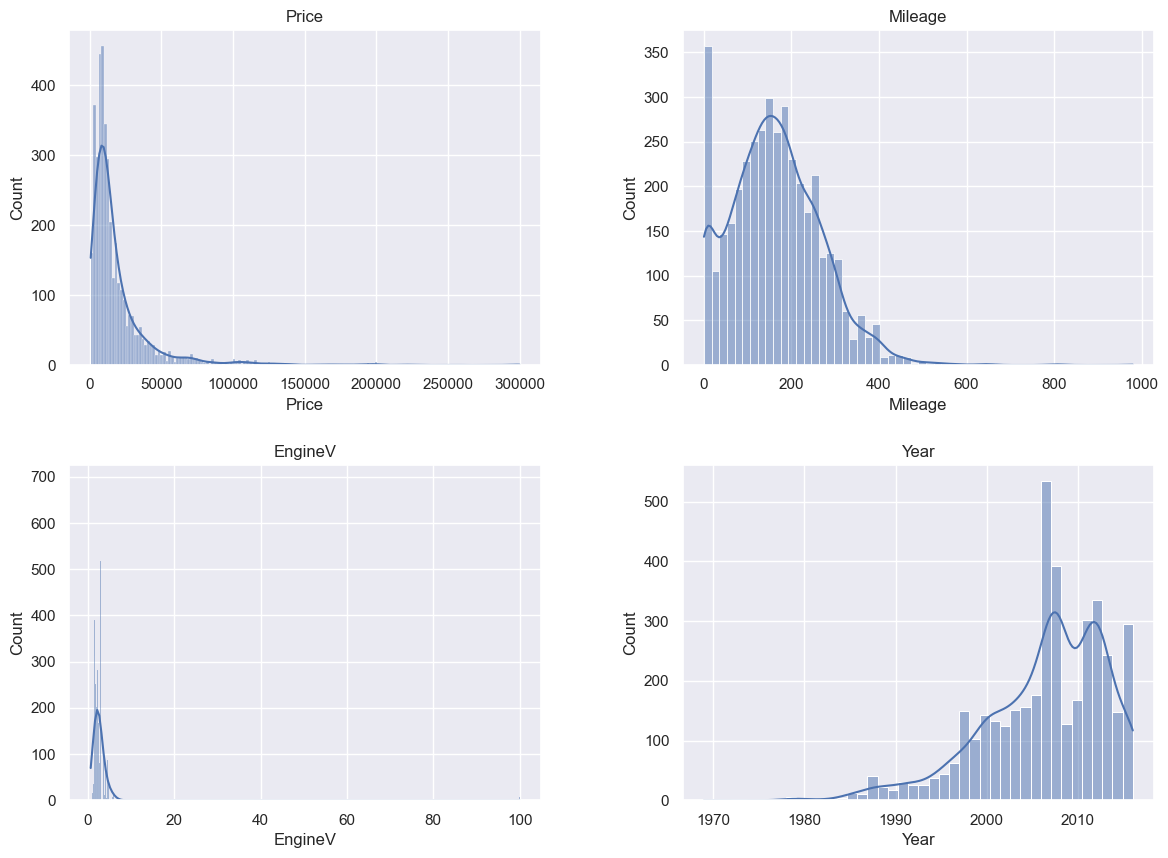

In [8]:
fig,axes = plt.subplots(2,2,figsize = (14,10))
plt.subplots_adjust(wspace=0.3, hspace=0.3)

sns.histplot(data_no_mv['Price'], ax= axes[0,0],kde = True)
axes[0,0].set_title('Price')

sns.histplot(data_no_mv['Mileage'], ax= axes[0,1],kde = True)
axes[0,1].set_title('Mileage')

sns.histplot(data_no_mv['EngineV'], ax= axes[1,0],kde = True)
axes[1,0].set_title('EngineV')

sns.histplot(data_no_mv['Year'], ax= axes[1,1],kde = True)
axes[1,1].set_title('Year')

### Dealing with outliers

Masing-masing feature bisa di'potong' berdasarkan bentuk grafiknya. Menggunakan fungsi QUANTILE.

In [9]:
data_1 = data_no_mv[data_no_mv['Price']<data_no_mv['Price'].quantile(0.99)]

data_2 = data_1[data_1['Mileage']<data_1['Mileage'].quantile(0.99)]

data_3 = data_2[data_2['EngineV']<6.5]

data_4 = data_3[data_3['Year']>data_3['Year'].quantile(0.01)]

data_cleaned = data_4.reset_index(drop=True)

data_cleaned.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
count,3867,3867.000000,3867,3867.000000,3867.000000,3867,3867,3867.000000
unique,7,NaN,6,NaN,NaN,4,2,NaN
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN
freq,848,NaN,1467,NaN,NaN,1807,3505,NaN
mean,NaN,18194.455679,NaN,160.542539,2.450440,NaN,NaN,2006.709853
std,NaN,19085.855165,NaN,95.633291,0.949366,NaN,NaN,6.103870
min,NaN,800.000000,NaN,0.000000,0.600000,NaN,NaN,1988.000000
25%,NaN,7200.000000,NaN,91.000000,1.800000,NaN,NaN,2003.000000
50%,NaN,11700.000000,NaN,157.000000,2.200000,NaN,NaN,2008.000000
75%,NaN,21700.000000,NaN,225.000000,3.000000,NaN,NaN,2012.000000


In [10]:
data_cleaned = (
    data_no_mv[data_no_mv['Price'] < data_no_mv['Price'].quantile(0.99)]
    .loc[lambda df: df['Mileage'] < df['Mileage'].quantile(0.99)]
    .loc[lambda df: df['EngineV'] < 6.5]
    .loc[lambda df: df['Year'] > df['Year'].quantile(0.01)]
    .reset_index(drop=True)
)

data_cleaned.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
count,3867,3867.000000,3867,3867.000000,3867.000000,3867,3867,3867.000000
unique,7,NaN,6,NaN,NaN,4,2,NaN
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN
freq,848,NaN,1467,NaN,NaN,1807,3505,NaN
mean,NaN,18194.455679,NaN,160.542539,2.450440,NaN,NaN,2006.709853
std,NaN,19085.855165,NaN,95.633291,0.949366,NaN,NaN,6.103870
min,NaN,800.000000,NaN,0.000000,0.600000,NaN,NaN,1988.000000
25%,NaN,7200.000000,NaN,91.000000,1.800000,NaN,NaN,2003.000000
50%,NaN,11700.000000,NaN,157.000000,2.200000,NaN,NaN,2008.000000
75%,NaN,21700.000000,NaN,225.000000,3.000000,NaN,NaN,2012.000000


In [11]:
data_filtered = data_no_mv[data_no_mv['Price']<data_no_mv['Price'].quantile(0.99)]

data_filtered = data_filtered[data_filtered['Mileage']<data_filtered['Mileage'].quantile(0.99)]

data_filtered = data_filtered[data_filtered['EngineV']<6.5]

data_filtered = data_filtered[data_filtered['Year']>data_filtered['Year'].quantile(0.01)]

data_cleaned = data_filtered.reset_index(drop=True)

data_cleaned.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year
count,3867,3867.000000,3867,3867.000000,3867.000000,3867,3867,3867.000000
unique,7,NaN,6,NaN,NaN,4,2,NaN
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN
freq,848,NaN,1467,NaN,NaN,1807,3505,NaN
mean,NaN,18194.455679,NaN,160.542539,2.450440,NaN,NaN,2006.709853
std,NaN,19085.855165,NaN,95.633291,0.949366,NaN,NaN,6.103870
min,NaN,800.000000,NaN,0.000000,0.600000,NaN,NaN,1988.000000
25%,NaN,7200.000000,NaN,91.000000,1.800000,NaN,NaN,2003.000000
50%,NaN,11700.000000,NaN,157.000000,2.200000,NaN,NaN,2008.000000
75%,NaN,21700.000000,NaN,225.000000,3.000000,NaN,NaN,2012.000000


### Compare the cleaned data & the raw data

Text(0.5, 1.0, 'Year "After Cleaned"')

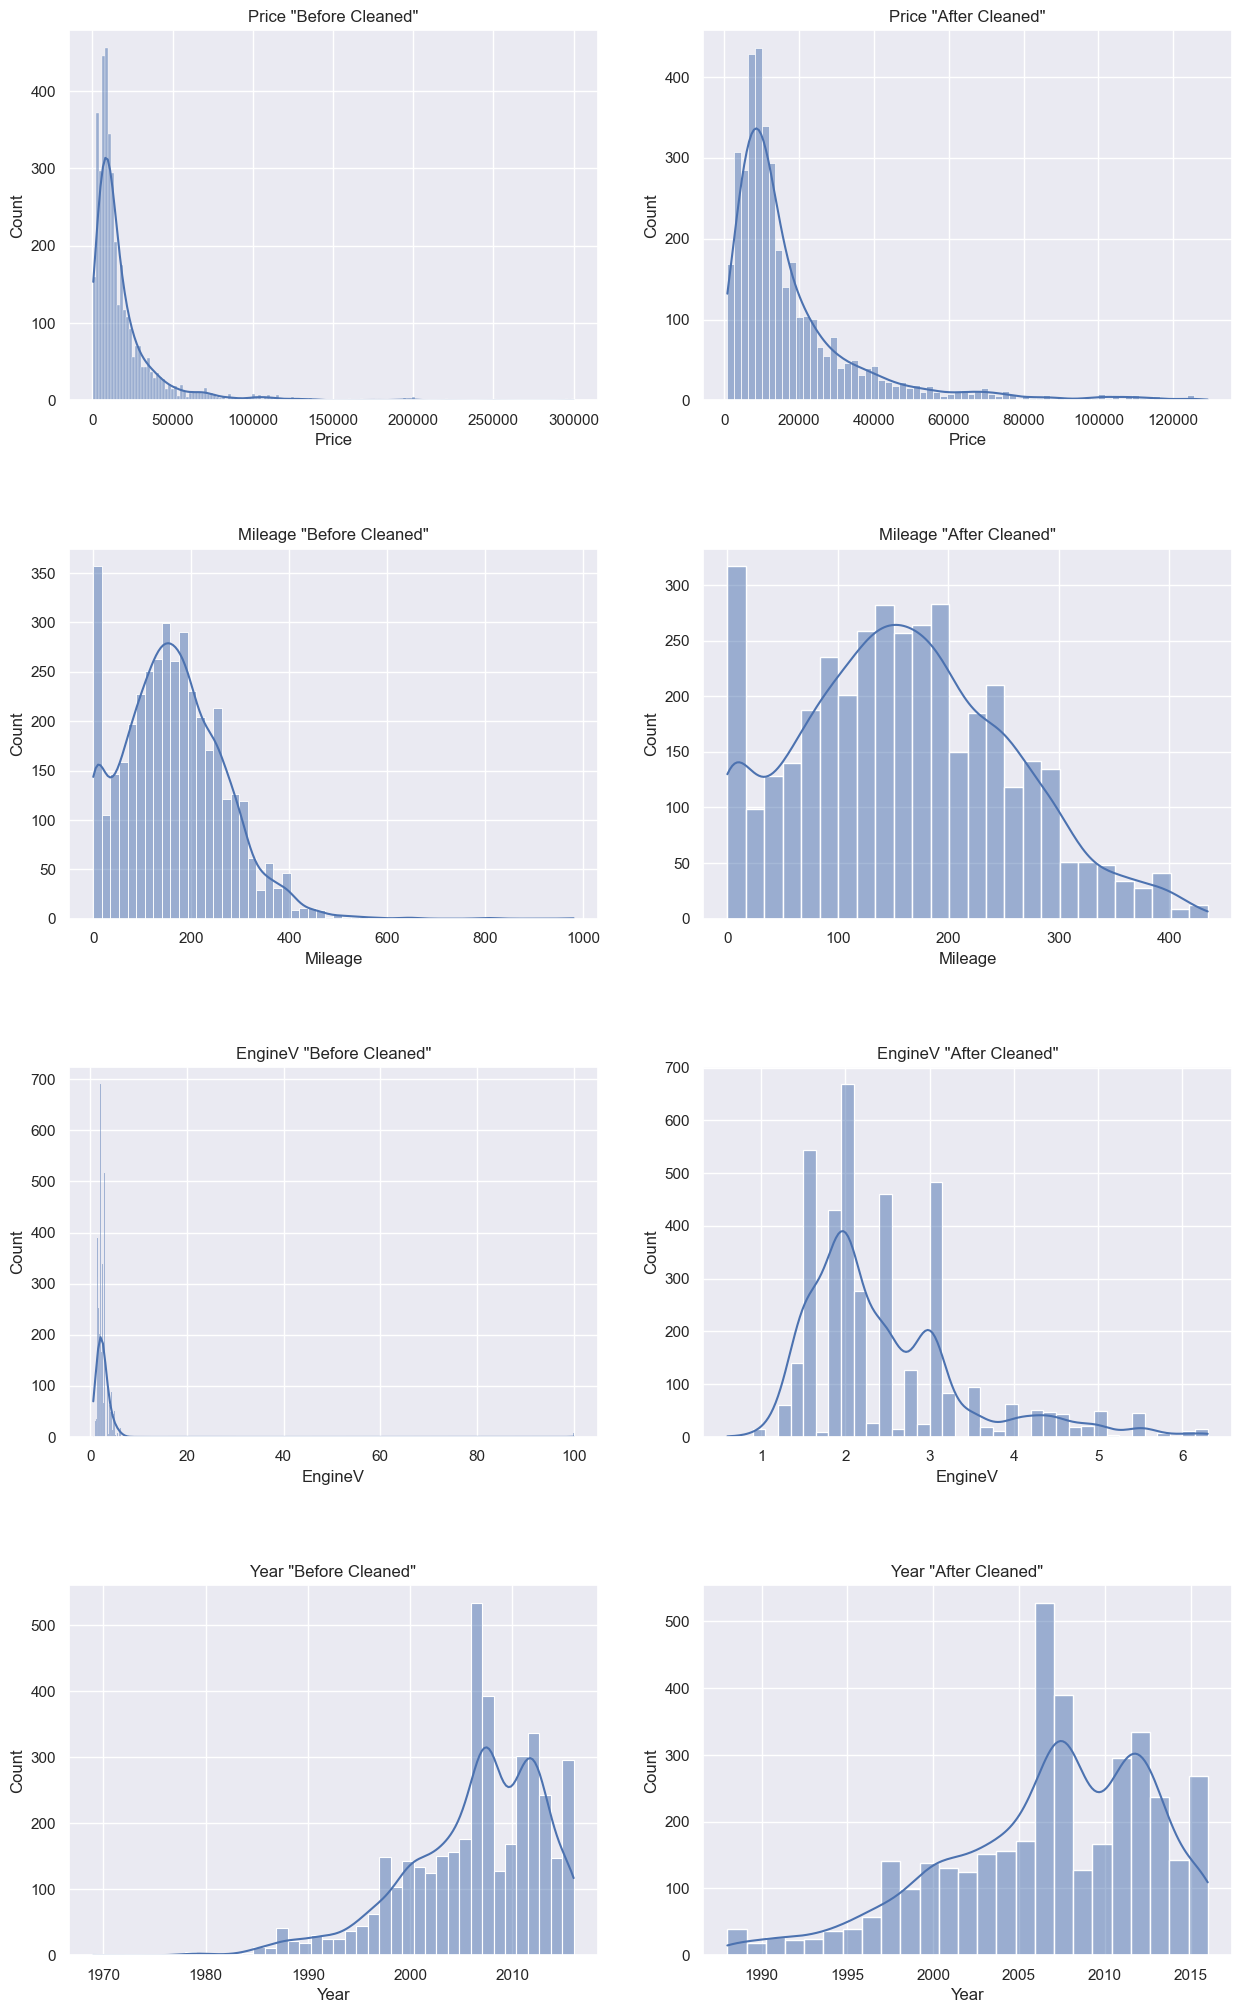

In [12]:

fig,axes = plt.subplots(4,2,figsize = (15,25))
plt.subplots_adjust(wspace=0.2, hspace=0.4)

sns.histplot(data_no_mv['Price'], ax= axes[0,0],kde = True)
axes[0,0].set_title('Price "Before Cleaned"')

sns.histplot(data_cleaned['Price'], ax= axes[0,1],kde = True)
axes[0,1].set_title('Price "After Cleaned"')

sns.histplot(data_no_mv['Mileage'], ax= axes[1,0],kde = True)
axes[1,0].set_title('Mileage "Before Cleaned"')

sns.histplot(data_cleaned['Mileage'], ax= axes[1,1],kde = True)
axes[1,1].set_title('Mileage "After Cleaned"')

sns.histplot(data_no_mv['EngineV'], ax= axes[2,0],kde = True)
axes[2,0].set_title('EngineV "Before Cleaned"')

sns.histplot(data_cleaned['EngineV'], ax= axes[2,1],kde = True)
axes[2,1].set_title('EngineV "After Cleaned"')

sns.histplot(data_no_mv['Year'], ax= axes[3,0],kde = True)
axes[3,0].set_title('Year "Before Cleaned"')

sns.histplot(data_cleaned['Year'], ax= axes[3,1],kde = True)
axes[3,1].set_title('Year "After Cleaned"')

## Checking The OLS Assumption

Text(0.5, 1.0, 'Mileage & Price')

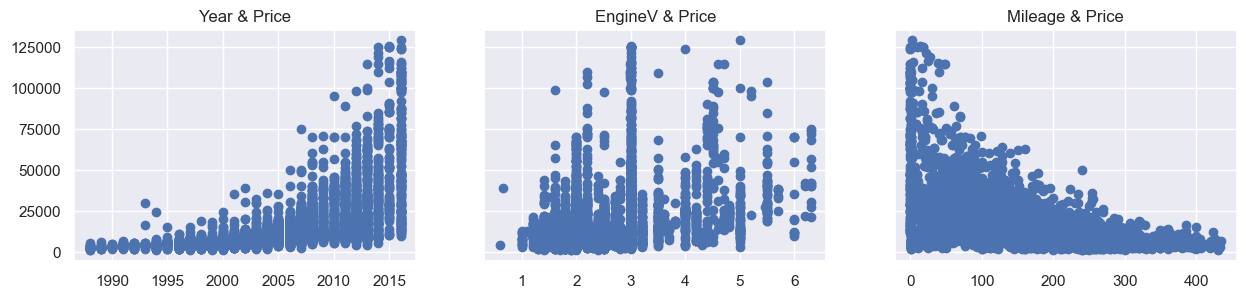

In [13]:
gambar,(ax1,ax2,ax3) = plt.subplots(1,3,sharey=True,figsize = (15,3))
ax1.scatter(data_cleaned['Year'],data_cleaned['Price'])
ax1.set_title('Year & Price')

ax2.scatter(data_cleaned['EngineV'],data_cleaned['Price'])
ax2.set_title('EngineV & Price')

ax3.scatter(data_cleaned['Mileage'],data_cleaned['Price'])
ax3.set_title('Mileage & Price')

Dari grafik diatas terlihat histogramnya berbentuk eksponensial (Heteroscedasticity) maka perlu di 'relax' kan menggunakan logaritma agar graifk tersebut memnuhi syarat homoscedasticity

### Relaxing the OLS Assumption (Remove Heteroscedasticity)

In [14]:
log_price = np.log(data_cleaned['Price'])
data_cleaned['Log Price'] = log_price
data_cleaned.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Log Price
count,3867,3867.000000,3867,3867.000000,3867.000000,3867,3867,3867.000000,3867.000000
unique,7,NaN,6,NaN,NaN,4,2,NaN,NaN
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN,NaN
freq,848,NaN,1467,NaN,NaN,1807,3505,NaN,NaN
mean,NaN,18194.455679,NaN,160.542539,2.450440,NaN,NaN,2006.709853,9.415703
std,NaN,19085.855165,NaN,95.633291,0.949366,NaN,NaN,6.103870,0.876616
min,NaN,800.000000,NaN,0.000000,0.600000,NaN,NaN,1988.000000,6.684612
25%,NaN,7200.000000,NaN,91.000000,1.800000,NaN,NaN,2003.000000,8.881836
50%,NaN,11700.000000,NaN,157.000000,2.200000,NaN,NaN,2008.000000,9.367344
75%,NaN,21700.000000,NaN,225.000000,3.000000,NaN,NaN,2012.000000,9.985068


Text(0.5, 1.0, 'Mileage & Price')

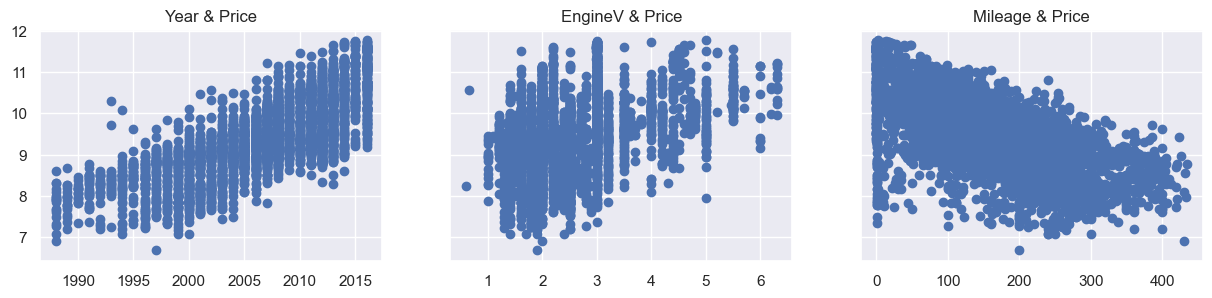

In [15]:
gambar,(ax1,ax2,ax3) = plt.subplots(1,3,sharey=True,figsize = (15,3))
ax1.scatter(data_cleaned['Year'],data_cleaned['Log Price'])
ax1.set_title('Year & Price')

ax2.scatter(data_cleaned['EngineV'],data_cleaned['Log Price'])
ax2.set_title('EngineV & Price')

ax3.scatter(data_cleaned['Mileage'],data_cleaned['Log Price'])
ax3.set_title('Mileage & Price')

Dari grafik searang terlihat tidak eksponensial lagi, tetapi terlihat linear. Maka dari grafik tersebut data sudah memenuhi syarat Homoscedasticity. Feature Price bisa dihilangkan dan diganti menggunakan Price yang sudah di Logaritma kan

In [16]:
data_cleaned = data_cleaned.drop(['Price'],axis = 1)
data_cleaned.describe(include='all')

,Brand,Body,Mileage,EngineV,Engine Type,Registration,Year,Log Price
count,3867,3867,3867.000000,3867.000000,3867,3867,3867.000000,3867.000000
unique,7,6,NaN,NaN,4,2,NaN,NaN
top,Volkswagen,sedan,NaN,NaN,Diesel,yes,NaN,NaN
freq,848,1467,NaN,NaN,1807,3505,NaN,NaN
mean,NaN,NaN,160.542539,2.450440,NaN,NaN,2006.709853,9.415703
std,NaN,NaN,95.633291,0.949366,NaN,NaN,6.103870,0.876616
min,NaN,NaN,0.000000,0.600000,NaN,NaN,1988.000000,6.684612
25%,NaN,NaN,91.000000,1.800000,NaN,NaN,2003.000000,8.881836
50%,NaN,NaN,157.000000,2.200000,NaN,NaN,2008.000000,9.367344
75%,NaN,NaN,225.000000,3.000000,NaN,NaN,2012.000000,9.985068


### Multicolinearity
Multicolinearity bisa dicek menggunakan Fungsi 'Variance Inflation Factor' atau VIF dari Statmodel

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
variables = data_cleaned[['Mileage','Year','EngineV']]
vif = pd.DataFrame()
vif['VIF'] = [variance_inflation_factor(variables.values,i) for i in range(variables.shape[1])]
vif['Features'] = variables.columns
vif

,VIF,Features
0,3.791584,Mileage
1,10.354854,Year
2,7.662068,EngineV


Multicolinearity dapat dilihat dari nilai VIF. Jika 
VIF : 1 maka No Multicolinearity.
1 < VIF < 5 maka Perfectly Okay.
VIF > 5 unacceptable.

Tapi pada kasus di dunia nyata akan jarang VIF < 5. Sehingga ada kasus tertentu VIF boleh diatas 5. Baca artikel dari Udemy atau tanya ChatGPT

======================================================================================================================================================

Kita bisa mencoba menghilangkan 'Year' karena memiliki nilai VIF yang sangat tinggi. 

In [18]:
data_no_multicolinearity =  data_cleaned.drop(['Year'],axis = 1)
data_no_multicolinearity

,Brand,Body,Mileage,EngineV,Engine Type,Registration,Log Price
0,BMW,sedan,277,2.0,Petrol,yes,8.342840
1,Mercedes-Benz,van,427,2.9,Diesel,yes,8.974618
2,Mercedes-Benz,sedan,358,5.0,Gas,yes,9.495519
3,Audi,crossover,240,4.2,Petrol,yes,10.043249
4,Toyota,crossover,120,2.0,Petrol,yes,9.814656
...,...,...,...,...,...,...,...
3862,Volkswagen,van,163,2.5,Diesel,yes,9.350102
3863,Toyota,sedan,35,1.6,Petrol,yes,9.792556
3864,Mercedes-Benz,sedan,9,3.0,Diesel,yes,11.736069
3865,BMW,sedan,1,3.5,Petrol,yes,8.779557


## Create Dummy Variables
We need to process categorial data. Before we do that we should convert the categorical data using dummies.

In [19]:
data_with_dummies =  pd.get_dummies(data_no_multicolinearity,drop_first= True)
data_with_dummies

,Mileage,EngineV,Log Price,Brand_BMW,Brand_Mercedes-Benz,Brand_Mitsubishi,Brand_Renault,Brand_Toyota,Brand_Volkswagen,Body_hatch,Body_other,Body_sedan,Body_vagon,Body_van,Engine Type_Gas,Engine Type_Other,Engine Type_Petrol,Registration_yes
0,277,2.0,8.342840,True,False,False,False,False,False,False,False,True,False,False,False,False,True,True
1,427,2.9,8.974618,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True
2,358,5.0,9.495519,False,True,False,False,False,False,False,False,True,False,False,True,False,False,True
3,240,4.2,10.043249,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
4,120,2.0,9.814656,False,False,False,False,True,False,False,False,False,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3862,163,2.5,9.350102,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True
3863,35,1.6,9.792556,False,False,False,False,True,False,False,False,True,False,False,False,False,True,True
3864,9,3.0,11.736069,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True
3865,1,3.5,8.779557,True,False,False,False,False,False,False,False,True,False,False,False,False,True,True


In [20]:
data_with_dummies.columns.values

array(['Mileage', 'EngineV', 'Log Price', 'Brand_BMW',
       'Brand_Mercedes-Benz', 'Brand_Mitsubishi', 'Brand_Renault',
       'Brand_Toyota', 'Brand_Volkswagen', 'Body_hatch', 'Body_other',
       'Body_sedan', 'Body_vagon', 'Body_van', 'Engine Type_Gas',
       'Engine Type_Other', 'Engine Type_Petrol', 'Registration_yes'],
      dtype=object)

In [21]:
col = ['Log Price','Mileage','EngineV','Brand_BMW',
       'Brand_Mercedes-Benz', 'Brand_Mitsubishi', 'Brand_Renault',
       'Brand_Toyota', 'Brand_Volkswagen', 'Body_hatch', 'Body_other',
       'Body_sedan', 'Body_vagon', 'Body_van', 'Engine Type_Gas',
       'Engine Type_Other', 'Engine Type_Petrol', 'Registration_yes']

In [22]:
data_preprocessed = data_with_dummies[col]
data_preprocessed

,Log Price,Mileage,EngineV,Brand_BMW,Brand_Mercedes-Benz,Brand_Mitsubishi,Brand_Renault,Brand_Toyota,Brand_Volkswagen,Body_hatch,Body_other,Body_sedan,Body_vagon,Body_van,Engine Type_Gas,Engine Type_Other,Engine Type_Petrol,Registration_yes
0,8.342840,277,2.0,True,False,False,False,False,False,False,False,True,False,False,False,False,True,True
1,8.974618,427,2.9,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True
2,9.495519,358,5.0,False,True,False,False,False,False,False,False,True,False,False,True,False,False,True
3,10.043249,240,4.2,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
4,9.814656,120,2.0,False,False,False,False,True,False,False,False,False,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3862,9.350102,163,2.5,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True
3863,9.792556,35,1.6,False,False,False,False,True,False,False,False,True,False,False,False,False,True,True
3864,11.736069,9,3.0,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True
3865,8.779557,1,3.5,True,False,False,False,False,False,False,False,True,False,False,False,False,True,True


## Linear Regression

### Declare Input and Output
Tentukan mana input dan output

In [23]:
target = data_preprocessed['Log Price']
inputs = data_preprocessed.drop(['Log Price'], axis=1)

### Scale the data
Distandarisasi dan di scale menggunakan sklearn.preprocessing - standardscaler. Data yang mengandung dummies tidak baik untuk di scaler karena akan mengubah makna dummies itu sendiri. Maka ada cara untuk melakukan scaler tanpa mengubah nilai dummies nya

In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(inputs)

StandardScaler()

Di Transformasikan agar berbentuk array

In [25]:
input_scaled = scaler.transform(inputs)
input_scaled

array([[ 1.2179077 , -0.47452478,  2.27971827, ..., -0.16209221,
         1.33267512,  0.32137366],
       [ 2.78660201,  0.47359854, -0.43865069, ..., -0.16209221,
        -0.75037043,  0.32137366],
       [ 2.06500263,  2.68588629, -0.43865069, ..., -0.16209221,
        -0.75037043,  0.32137366],
       ...,
       [-1.58482613,  0.57894557, -0.43865069, ..., -0.16209221,
        -0.75037043,  0.32137366],
       [-1.66848982,  1.10568075,  2.27971827, ..., -0.16209221,
         1.33267512,  0.32137366],
       [-0.38216049, -0.47452478, -0.43865069, ..., -0.16209221,
        -0.75037043,  0.32137366]])

### Membagi Data Train dan Data Test
Train-test split sebelum linear regression untuk memastikan bahwa model yang kita bangun bisa menggeneralisasi dengan baik ke data yang belum pernah dilihat sebelumnya

In [26]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(input_scaled,target, test_size= 0.2, random_state= 365)


### Linear Regression
Linear Regression yang digunakan adalah log. Hal ini karena data dependent nya berupa log ['Log Price']

In [27]:
reg = LinearRegression()
reg.fit(x_train,y_train)

LinearRegression()

### Pengecekan Model
Mengecek hasilnya adalah meng plot kan predicted values (y hat = predicted dari x train) terhadap observed values (y train)

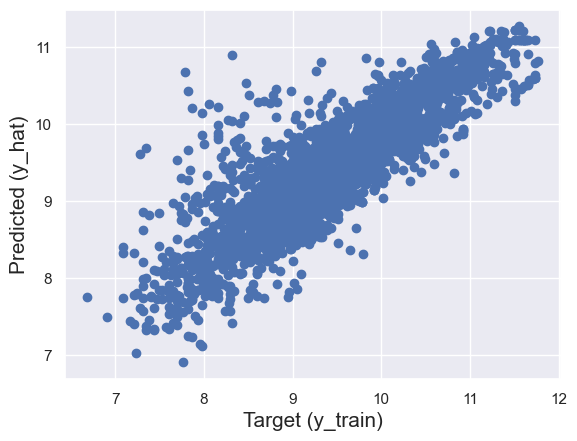

In [28]:
y_hat = reg.predict(x_train)

plt.scatter(y_train,y_hat)
plt.xlabel('Target (y_train)',size = 15)
plt.ylabel('Predicted (y_hat)',size = 15)
plt.show()

Alternative dari scatter adalah kita bisa mengecek Residual atau perbedaan antara predicted values dan observed values kemudian di gambarkan menggunakan histogram. Dari situ bisa terlihat syarat syarat Linear Regression

Text(0.5, 1.0, 'Residual')

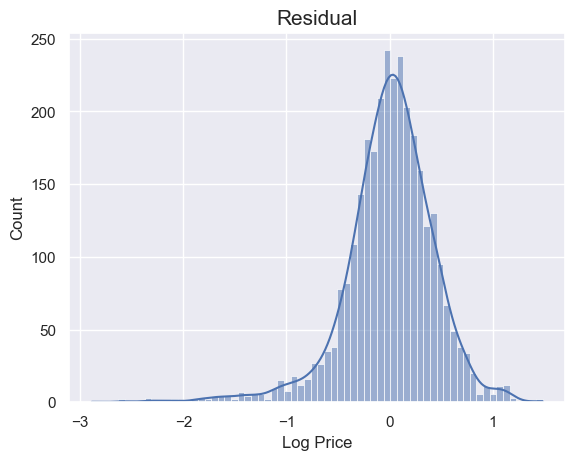

In [29]:
sns.histplot(y_train - y_hat,kde = True)
plt.title('Residual',size = 15)

Dari histogram diatas kita bisa melihat syarat dari normaity dan homoscedasticity, yaitu : - Zero Mean (rata2 = 0), -Normality, - Homoscedasticity (grafiknya tidak eksponensial).

Jika dari grafik diatas pada nilai negatif memiliki ekor yang panjang. Hal tersebut bisa disimpulkan (y_train - y_hat) jauh dibawah dari rata2. Atau harga yang diprediksi lebih tinggi dari yang diobservasi

In [30]:
reg.score(x_train,y_train)

0.744996578792662

Hasil dari R squared adalah 0.7449 ..... maka disimpulkan model tersebut menjelaskan sekitar 75 % dari variablity dari data. Bisa dikatakan hasil yang bagus

### Menemukan Weights dan Bias
Untuk meentukan feature mana yang memiliki peran terhadap model

In [31]:
reg.intercept_

9.415239458021299

In [32]:
reg.coef_

array([-0.44871341,  0.20903483,  0.0142496 ,  0.01288174, -0.14055166,
       -0.17990912, -0.06054988, -0.08992433, -0.1454692 , -0.10144383,
       -0.20062984, -0.12988747, -0.16859669, -0.12149035, -0.03336798,
       -0.14690868,  0.32047333])

In [33]:
reg_summaries = pd.DataFrame(inputs.columns.values, columns = ['Feature'])
reg_summaries ['Weight'] = reg.coef_
reg_summaries

,Feature,Weight
0,Mileage,-0.448713
1,EngineV,0.209035
2,Brand_BMW,0.014250
3,Brand_Mercedes-Benz,0.012882
4,Brand_Mitsubishi,-0.140552
5,Brand_Renault,-0.179909
6,Brand_Toyota,-0.060550
7,Brand_Volkswagen,-0.089924
8,Body_hatch,-0.145469
9,Body_other,-0.101444


In [34]:
data_cleaned['Brand'].unique()

array(['BMW', 'Mercedes-Benz', 'Audi', 'Toyota', 'Renault', 'Volkswagen',
       'Mitsubishi'], dtype=object)

In [35]:
data_cleaned['Engine Type'].unique()

array(['Petrol', 'Diesel', 'Gas', 'Other'], dtype=object)

In [36]:
data_cleaned['Body'].unique()

array(['sedan', 'van', 'crossover', 'vagon', 'other', 'hatch'],
      dtype=object)

In [37]:
data_cleaned['Registration'].unique()

array(['yes', 'no'], dtype=object)

##################################################PENJELASAN WEIGHT###########################################################

Dari tabel tersebut belum bisa di jelaskan karena semua masih dalam bentuk standarized termasuk feature 'Dummies' nya. Tapi bisa dijelaskan secara POSITVE dan NEGATIVE nya.

---------------------------------------CONTINUOUS VARIABLE (Variabel yang value fiturnya adalah angka)---------------------------------------

Pada feature POSITIVE = semakin bertambah nilai pada feature nya maka nilai targetnya ber TAMBAH. Contoh pada fitur EngineV, jika EngineV semakin besar maka harga semakin tinggi.

Pada feature NEGATIVE = semakin bertambah nilai pada feature nya maka nilai targetnya ber KURANG. Contoh pada fitur Mileage, jika Mile nya semakin tinggi maka harga semakin turun.

---------------------------------------DUMMIES VARIABLE (Variabel yang value fiturnya adalah dummies)---------------------------------------

Pada proses 'data_with_dummies' sebelumnya diperintahkan 'dropFirst = True'. Dimana mengacu pada feature dummies yang tidak ada di tabel weight. Pada kasus ini adalah brand AUDI. Maka AUDI adalah brand yang digunakan sebagai benchmark

Pada feature POSITIVE = Nilai harga brand tersebut lebih MAHAL / TINGGI dari BENCHMARK . Contoh pada brand Mercedes Benz dan BMW lebih mahal dari Audi.

Pada feature NEGATIVE = Nilai harga brand tersebut lebih MURAH / RENDAH dari BENCHMARK . Contoh pada brand Mitsubishi, Toyota, Renault, dan Volkswagen lebih murah dari Audi.

## Testing

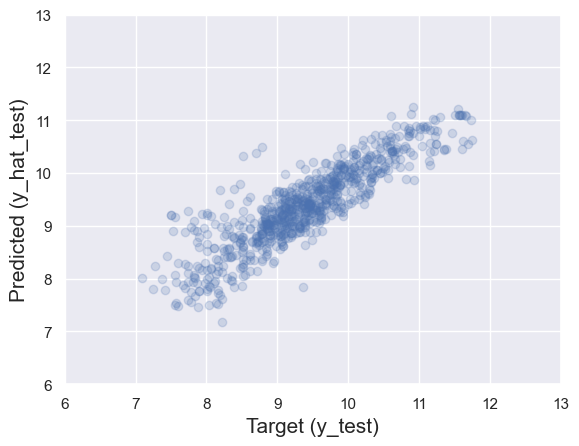

In [38]:
y_hat_test = reg.predict(x_test)

plt.scatter(y_test,y_hat_test,alpha=0.2)
plt.xlabel('Target (y_test)',size = 15)
plt.ylabel('Predicted (y_hat_test)',size = 15)
plt.xlim(6,13)
plt.ylim(6,13)
plt.show()

In [39]:
residual_test = pd.DataFrame(np.exp(y_hat_test), columns = ['Prediction'])
residual_test

,Prediction
0,10685.501696
1,3499.255242
2,7553.285218
3,7463.963017
4,11353.490075
...,...
769,29651.726363
770,10732.071179
771,13922.446953
772,27487.751303


In [40]:
y_test = y_test.reset_index(drop=True)
residual_test['Target'] = np.exp(y_test)
residual_test['Residual'] = residual_test['Target'] - residual_test['Prediction']
residual_test

,Prediction,Target,Residual
0,10685.501696,2300.0,-8385.501696
1,3499.255242,2800.0,-699.255242
2,7553.285218,2500.0,-5053.285218
3,7463.963017,6400.0,-1063.963017
4,11353.490075,9150.0,-2203.490075
...,...,...,...
769,29651.726363,29500.0,-151.726363
770,10732.071179,9600.0,-1132.071179
771,13922.446953,18300.0,4377.553047
772,27487.751303,68500.0,41012.248697


In [41]:
residual_test['Difference%'] = np.absolute(residual_test['Residual']/ residual_test['Target']*100)
residual_test

,Prediction,Target,Residual,Difference%
0,10685.501696,2300.0,-8385.501696,364.587030
1,3499.255242,2800.0,-699.255242,24.973402
2,7553.285218,2500.0,-5053.285218,202.131409
3,7463.963017,6400.0,-1063.963017,16.624422
4,11353.490075,9150.0,-2203.490075,24.081859
...,...,...,...,...
769,29651.726363,29500.0,-151.726363,0.514327
770,10732.071179,9600.0,-1132.071179,11.792408
771,13922.446953,18300.0,4377.553047,23.921055
772,27487.751303,68500.0,41012.248697,59.871896


In [42]:
residual_test.describe()

,Prediction,Target,Residual,Difference%
count,774.000000,774.000000,774.000000,774.000000
mean,15946.760167,18165.817106,2219.056939,36.256693
std,13133.197604,19967.858908,10871.218143,55.066507
min,1320.562768,1200.000000,-29456.498331,0.062794
25%,7413.644234,6900.000000,-2044.191251,12.108022
50%,11568.168859,11600.000000,142.518577,23.467728
75%,20162.408805,20500.000000,3147.343497,39.563570
max,77403.055224,126000.000000,85106.162329,512.688080


### Kesimpulan
Jika dilihat dari histogram dan tabel diferensasi maka terlihat model kita kurang optimal dalam memprediksi harga mobil. Bahkan sampai beberapa perbedaan mencapai diatas 200%. Model ini bisa dirubah atau diperbaiki mungkin dengan mengikutkan Feature "Brand Model" dan mencoba data terus menerus